# Figure 1.2 — Parametric characterisation of representational drift

Combined three-panel figure:

| Panel | Content |
|-------|---------|
| **A** | Drift rate Δ across the E × σ parameter space (heatmap) |
| **B** | Population-state trajectories in PC space across four mechanistic conditions |
| **C** | Hebbian learning rate η vs. synaptic weight variance and drift rate |

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA

sys.path.insert(0, os.getcwd())
from model import (ModelParams, get_or_run,
                   compute_population_vectors,
                   run_grid_sweep, run_tauw_sweep)
from plot_style import apply_style, COLORS, CMAPS, FIG_SIZES, FONT, LW, LINEWIDTH_IN

NOTEBOOK_DIR = os.path.abspath("")
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, "saved_figures")
DATA_DIR     = os.path.join(NOTEBOOK_DIR, "data")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

## Parameters

Edit the blocks below to change any individual panel. Simulations are cached — only changed
parameter combinations re-run.

In [2]:
base_params = ModelParams()

# ── Panel A: E × σ grid ───────────────────────────────────────────────────────
E_values       = [0.0, 0.5, 1.0, 1.5, 2.0]
vol_std_values = [0.0, 0.01, 0.02, 0.04, 0.06]
seeds_A        = [0, 1, 2]

# ── Panel B: PCA conditions ───────────────────────────────────────────────────
seed_B     = 0
conditions = [
    dict(E=0.0, E_sigma=0.0, vol_std=0.00, label="No drift  (E=0, σ=0)",       color="#999999"),
    dict(E=1.5, E_sigma=1.0, vol_std=0.00, label="Excit. only (E=1.5, σ=0)",   color="#2196F3"),
    dict(E=0.0, E_sigma=0.0, vol_std=0.02, label="Vol. only  (E=0, σ=0.02)",   color="#FF9800"),
    dict(E=1.5, E_sigma=1.0, vol_std=0.02, label="Combined  (E=1.5, σ=0.02)",  color="#E91E63"),
]

# ── Panel C: learning-rate sweep ──────────────────────────────────────────────
n_lr_points   = 20
lr_min, lr_max = 0.0001, 0.5
seeds_C       = [0, 1, 2]

# ── Plot-data cache ───────────────────────────────────────────────────────────
CACHE_PATH = os.path.join(DATA_DIR, "fig1_2_plotdata.npz")

In [3]:
# ── Load cached plot data (skip simulations on subsequent runs) ───────────────
_loaded_cache = False
if os.path.exists(CACHE_PATH):
    _c        = np.load(CACHE_PATH, allow_pickle=True)
    drift_A   = _c["drift_A"]
    projs     = [_c["projs"][i] for i in range(len(_c["projs"]))]
    ev_ratios = _c["ev_ratios"]
    lr_arr    = _c["lr_arr"]
    drift_C   = _c["drift_C"]
    drift_sem = _c["drift_sem"]
    wvar_mean = _c["wvar_mean"]
    wvar_sem  = _c["wvar_sem"]
    _loaded_cache = True
    print(f"Loaded plot data from cache ({CACHE_PATH})")
else:
    print("No cache found — simulations will run.")

No cache found — simulations will run.


In [4]:
# ── Panel A data ──────────────────────────────────────────────────────────────
if not _loaded_cache:
    sweep_A = run_grid_sweep(E_values, vol_std_values, seeds_A,
                             base_params=base_params, name="fig1_2_1_sweep")
    drift_A = sweep_A["drift"].mean(axis=2)   # (nE, nvol)
    print(f"[A] Drift: min={drift_A.min():.3f}  max={drift_A.max():.3f}")

  [75/75] E=2.00  vol_std=0.0600  seed=2
[A] Drift: min=0.005  max=3.161


In [5]:
# ── Panel B data ──────────────────────────────────────────────────────────────
if not _loaded_cache:
    cond_vecs = []
    for cond in conditions:
        p    = ModelParams(E=cond["E"], E_sigma=cond.get("E_sigma", 1.0),
                           vol_std=cond["vol_std"], seed=seed_B)
        name = f"pca_E{cond['E']}_Esig{p.E_sigma}_vol{cond['vol_std']}_s{seed_B}"
        res  = get_or_run(p, name)
        if res["params"] != p:
            res = get_or_run(p, name, force=True)
        cond_vecs.append(compute_population_vectors(res))

    pca       = PCA(n_components=2)
    pca.fit(np.vstack(cond_vecs))
    projs     = [pca.transform(V) for V in cond_vecs]
    ev_ratios = pca.explained_variance_ratio_[:2]
    print(f"[B] PC1 {ev_ratios[0]*100:.1f}%  PC2 {ev_ratios[1]*100:.1f}%")

Running simulation (seed=0, E=0.0, vol_std=0.0) ...
Running simulation (seed=0, E=1.5, vol_std=0.0) ...
Running simulation (seed=0, E=0.0, vol_std=0.02) ...
Running simulation (seed=0, E=1.5, vol_std=0.02) ...
[B] PC1 29.5%  PC2 14.5%


In [6]:
# ── Panel C data ──────────────────────────────────────────────────────────────
if not _loaded_cache:
    lr_values   = np.logspace(np.log10(lr_min), np.log10(lr_max), n_lr_points)
    tauw_values = 1.0 / lr_values

    sweep_C   = run_tauw_sweep(tauw_values, seeds_C,
                               base_params=base_params, name="fig1_2_3_tauw_sweep")
    lr_arr    = sweep_C["lr_values"]
    drift_C   = sweep_C["drift"].mean(axis=1)
    drift_sem = sweep_C["drift"].std(axis=1)  / np.sqrt(len(seeds_C))
    wvar_mean = sweep_C["weight_var"].mean(axis=1)
    wvar_sem  = sweep_C["weight_var"].std(axis=1) / np.sqrt(len(seeds_C))
    print(f"[C] lr range: {lr_arr.min():.4f} – {lr_arr.max():.3f}")

  [60/60] tauw=2.0  seed=2222
[C] lr range: 0.0001 – 0.500


In [7]:
# ── Save minimal plot data to cache ──────────────────────────────────────────
if not _loaded_cache:
    np.savez(CACHE_PATH,
             drift_A   = drift_A,
             projs     = np.array(projs),   # shape (n_conds, n_days, 2)
             ev_ratios = ev_ratios,          # shape (2,)
             lr_arr    = lr_arr,
             drift_C   = drift_C,
             drift_sem = drift_sem,
             wvar_mean = wvar_mean,
             wvar_sem  = wvar_sem)
    print(f"Plot data cached -> {CACHE_PATH}")

Plot data cached -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\data\fig1_2_plotdata.npz


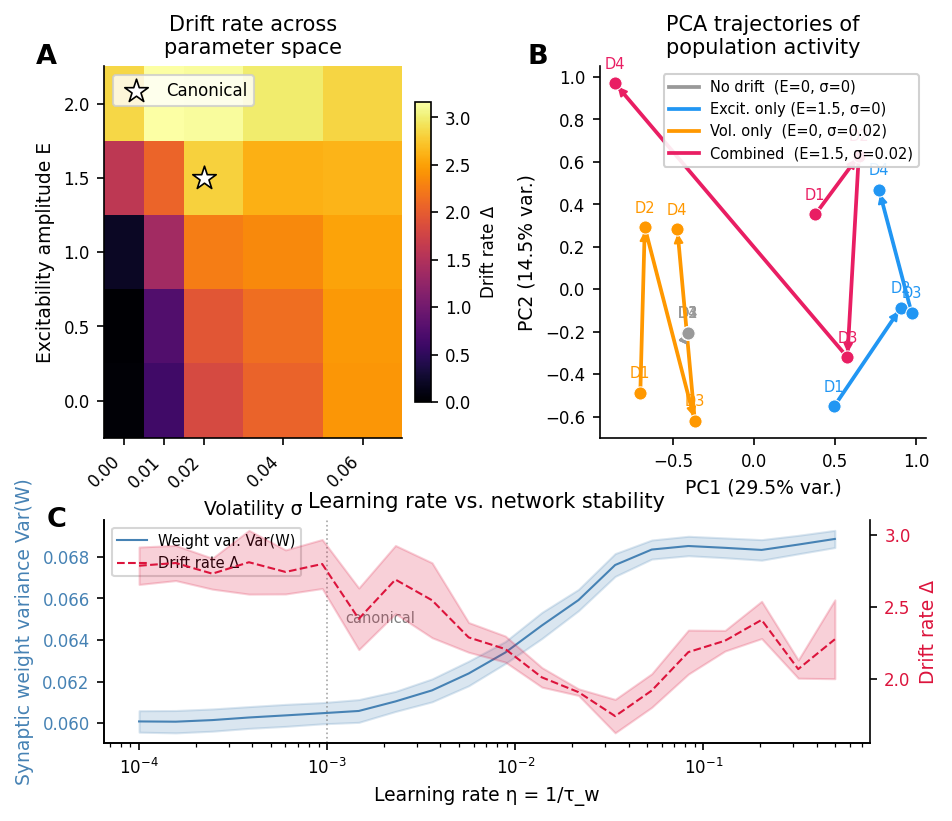

In [8]:
apply_style()

fig = plt.figure(figsize=(LINEWIDTH_IN, 5.5))

# Top row: A (heatmap) and B (PCA), equal half-width
gs_top = gridspec.GridSpec(1, 2, figure=fig,
                           left=0.10, right=0.97,
                           top=0.95, bottom=0.50,
                           wspace=0.52)

# Bottom row: C (full width). Right margin reserves space for twinx y-label.
gs_bot = gridspec.GridSpec(1, 1, figure=fig,
                           left=0.10, right=0.91,
                           top=0.40, bottom=0.13)

ax_A = fig.add_subplot(gs_top[0])
ax_B = fig.add_subplot(gs_top[1])
ax_C = fig.add_subplot(gs_bot[0])

def _label(ax, txt, x=-0.16, y=1.06):
    ax.text(x, y, txt, transform=ax.transAxes,
            fontsize=FONT["panel_label"], fontweight="bold", va="top", ha="right")


# ── Panel A — Heatmap ─────────────────────────────────────────────────────────
E_arr   = np.array(E_values)
vol_arr = np.array(vol_std_values)
X, Y    = np.meshgrid(vol_arr, E_arr)

pcm = ax_A.pcolormesh(X, Y, drift_A, cmap=CMAPS["heatmap"], shading="auto", vmin=0)
cb  = plt.colorbar(pcm, ax=ax_A, pad=0.04, fraction=0.046)
cb.set_label("Drift rate Δ", fontsize=FONT["colorbar"])

ax_A.scatter([base_params.vol_std], [base_params.E],
             marker="*", s=140, color="white", edgecolors="black", lw=0.8,
             zorder=5, label="Canonical")
ax_A.legend(fontsize=FONT["annotation"], loc="upper left")
ax_A.set_xlabel("Volatility σ")
ax_A.set_ylabel("Excitability amplitude E")
ax_A.set_title("Drift rate across\nparameter space")
ax_A.set_xticks(vol_arr)
ax_A.set_yticks(E_arr)
ax_A.set_xticklabels([f"{v:.2f}" for v in vol_arr],
                     rotation=45, ha="right", fontsize=FONT["tick"])
ax_A.set_yticklabels([f"{e:.1f}" for e in E_arr], fontsize=FONT["tick"])
_label(ax_A, "A")


# ── Panel B — PCA trajectories ────────────────────────────────────────────────
all_y = np.concatenate([proj[:, 1] for proj in projs])
y_off = (all_y.max() - all_y.min()) * 0.035

for cond, proj in zip(conditions, projs):
    col   = cond["color"]
    Ndays = len(proj)
    ax_B.plot(proj[:, 0], proj[:, 1], color=col, lw=LW["trace"] * 1.8,
              label=cond["label"], zorder=3)
    for d in range(Ndays - 1):
        ax_B.annotate("",
                      xy    =(proj[d+1, 0], proj[d+1, 1]),
                      xytext=(proj[d,   0], proj[d,   1]),
                      arrowprops=dict(arrowstyle="-|>", color=col, lw=1.0),
                      zorder=4)
    for d in range(Ndays):
        ax_B.scatter(proj[d, 0], proj[d, 1], color=col, s=40,
                     zorder=5, edgecolors="white", lw=0.5)
        ax_B.text(proj[d, 0], proj[d, 1] + y_off,
                  f"D{d+1}", fontsize=FONT["annotation"] - 1, color=col,
                  ha="center", va="bottom")

ax_B.set_xlabel(f"PC1 ({ev_ratios[0]*100:.1f}% var.)")
ax_B.set_ylabel(f"PC2 ({ev_ratios[1]*100:.1f}% var.)")
ax_B.set_title("PCA trajectories of\npopulation activity")
ax_B.legend(fontsize=FONT["annotation"] - 1, loc="best", framealpha=0.9)
_label(ax_B, "B")


# ── Panel C — Learning rate vs stability (full-width bottom row) ───────────────
col_wvar  = COLORS["input"]
col_drift = COLORS["highlight"]

ax_C.plot(lr_arr, wvar_mean, color=col_wvar, lw=LW["trace"], label="Weight var. Var(W)")
ax_C.fill_between(lr_arr, wvar_mean - wvar_sem, wvar_mean + wvar_sem,
                  color=col_wvar, alpha=0.2)
ax_C.set_xscale("log")
ax_C.set_xlabel("Learning rate η = 1/τ_w")
ax_C.set_ylabel("Synaptic weight variance Var(W)", color=col_wvar)
ax_C.tick_params(axis="y", labelcolor=col_wvar)

ax_C2 = ax_C.twinx()
ax_C2.plot(lr_arr, drift_C, color=col_drift, lw=LW["trace"], ls="--",
           label="Drift rate Δ")
ax_C2.fill_between(lr_arr, drift_C - drift_sem, drift_C + drift_sem,
                   color=col_drift, alpha=0.2)
ax_C2.set_ylabel("Drift rate Δ", color=col_drift)
ax_C2.tick_params(axis="y", labelcolor=col_drift)
ax_C2.spines["right"].set_visible(True)

canon_lr = 1.0 / base_params.tauw
ax_C.axvline(canon_lr, color="gray", lw=0.8, ls=":", alpha=0.7)
ax_C.text(canon_lr * 1.25, wvar_mean.max() * 0.95,
          "canonical", fontsize=FONT["annotation"] - 1, color="gray", va="top")

lines1, labs1 = ax_C.get_legend_handles_labels()
lines2, labs2 = ax_C2.get_legend_handles_labels()
ax_C.legend(lines1 + lines2, labs1 + labs2,
            fontsize=FONT["annotation"] - 1, loc="upper left")
ax_C.set_title("Learning rate vs. network stability")
_label(ax_C, "C", x=-0.05)

plt.show()

In [9]:
out_path = os.path.join(FIGURES_DIR, "fig1_2_combined.pdf")
plt.tight_layout()  # Adjust layout to prevent clipping of labels
fig.savefig(out_path, dpi=300)
print(f"Figure saved -> {out_path}")

Figure saved -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\saved_figures\fig1_2_combined.pdf


<Figure size 960x720 with 0 Axes>